## Assignment 2

This assignmemt is based on content discussed in module 2 and will work on a solution for the famous Monty Hall game.  Retrieved from https://en.wikipedia.org/wiki/Monty_Hall_problem


## Learning outcomes

- Program a simple simulation to solve a concrete statistical problem
- Develop insight into the Bayesian probabilistic viewpoint
- Recognize that statistical intuition can sometimes be wrong


**Question**

Given below is the description of the problem.  

Suppose you're on a game show and you're given the choice of three doors. 

Behind one door is a car; behind the others, goats. The car and the goats were placed randomly behind the doors before the show.

The rules are:

After you have chosen a door, the door remains closed for the time being. 
The game show host, Monty Hall, who knows what is behind the doors, now has to open one of the two remaining doors, and the door he opens must have a goat behind it. If both remaining doors have goats behind them, he chooses one randomly. 

After Monty opens a door with a goat, he will ask you to decide whether you want to stay with your first choice or to switch to the last remaining door. 
Imagine that you chose Door 1 and the host opens Door 3, which has a goat. 
He then asks you "Do you want to switch to Door Number 2?" Is it to your advantage to change your choice? 

**NOTES:**
1. The player may initially choose any of the three doors (not just Door 1).
2. The host opens a different door revealing a goat (not necessarily Door 3).
3. The host gives the player a second choice between the two remaining unopened doors. 


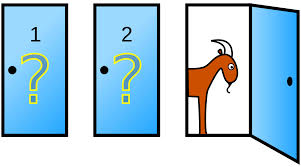

(Source: https://en.wikipedia.org/wiki/Monty_Hall_problem#)

- Write Python code to solve the Monty Hall problem. Simulate at least a thousand games using three doors for each strategy and show the results in such a way as to make it easy to compare the effects of each strategy.


### Summary

The following Monty Hall Simulation is implemented using an abstract base class, Monty_Hall_Simulation, and three derived classes to implement three different strategies.  An Object-Oriented design model was used as the trials are conducted exactly the same except for each individual strategy.

The following strategies will be simulated:

- **No Change**: the player does not change their original Door choice.
- **Change**: the player changes their original Door choice to the Door that Monty Hall did not choose.
- **Random**: during each trial, the player, at random, either keeps their original Door choice or changes their Door choice to the Door that Monty Hall did not choose.

Given the background information on the Monty Hall problem at the Wikipedia URL, the expected probabilities are:

- **No Change**: the player has a 1/3 chance selecting the car
- **Change**: the player has a 2/3 chance selecting the car
- **Random**: the player's chance of selecting the car is:  1/3 < X < 2/3

### Implementation

Each of the above strategy simulations is run through 10,000 trials.  In each trial, the Door prizes (i.e., car, goat, goat) are randomly assigned to each Door.  In each trial, the player also chooses a Door at random for their original choice.  For analysis and reporting purposes, the results of each simulation (i.e., the number of wins and losses) are stored in a DataFrame.

In [1]:
# Import libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
from abc import ABC, abstractmethod

In [2]:
# Set the debugging mode for printing.

_debug = False


In [3]:
# Abstract class

class Monty_Hall_Simulation(ABC):
    
    # Define the list of three possible prizes.
    
    prize_list = [ 'car', 'goat', 'goat']

    
    def __init__(self, strategy_name):

        """Constructor.

        Parameters
        ----------
        strategy_name : String
            The name of the strategy to implement for this Monty Hall simulation.

        Examples
        --------
        >>> myNoChangeStrategy = NoChangeStrategy("No Change Strategy")
        """   
        
        # Set the attribute including the blank DataFrame.
        
        self.strategy_name = strategy_name
        self.df = pd.DataFrame(columns=['Wins', 'Losses', 'Win Percentage', 'Strategy'])

        
    def run_simulation(self, trials=10000):

        """Run the Monty Hall simulation.

        Parameters
        ----------
        trials : int, optional
            The number of trials for this Monty Hall simulation.
            
        Examples
        --------
        >>> myChange.run_simulation
        """
    
        door_prize_list = []
        wins, losses = 0, 0
        
        # Run the simulation for the specified number of trials.
        
        for i in range(trials):
    
            # Create a list of three random numbers from 1 - 3 to
            # essentially create a random order of the prizes for each Door.
    
            lst = random.sample(range(1,4),3)

            # Using the random numbers, create the Door dictionary with the 
            # prizes "behind" each door.
            
            door_dict = { "Door 1" : Monty_Hall_Simulation.prize_list[lst[0]-1], 
                          "Door 2" : Monty_Hall_Simulation.prize_list[lst[1]-1],
                          "Door 3" : Monty_Hall_Simulation.prize_list[lst[2]-1] }

            if _debug: print (door_dict)

            # The player starts by choosing one of the Doors at random.
            
            door_choice = random.sample(range(1,4), 3)
            player_choice = door_choice[0]
    
            if _debug: print("Player chose Door ", str(player_choice), door_dict["Door " + str(player_choice)])

            # Monty now makes his choice based on the player's choice.  Monty can
            # only open up one of the doors that contains a goat.

            if door_dict["Door " + str(player_choice)] == 'car':

                # The player correctly selected the Door with the car.  That leaves the
                # remaining doors with both goats.  Monty can choose at random.
                
                if _debug: print("Random between", door_choice[1], "and", door_choice[2])
                monty_choice = random.choice([door_choice[1], door_choice[2]])
        
                # Keep track of the remaining door that Monty didn't choose.
            
                monty_other_choice = door_choice[2] if monty_choice == door_choice[1] else door_choice[1]

            else:

                # The player chose a Door with a goat.  That leaves Monty with only
                # one Door option - the other Door with the goat.
                
                if door_dict["Door " + str(door_choice[1])] == 'car':
                    
                    # The Door contains the car.  Therefore, choose the other Door.
                    
                    monty_choice = door_choice[2]
                    monty_other_choice = door_choice[1]
                    
                else:
                    
                    # The Door contains the goat.  Therefore, choose this Door.
                    
                    monty_choice = door_choice[1]
                    monty_other_choice = door_choice[2]

            if _debug: print("Monty chose", monty_choice, "->", door_dict["Door " + str(monty_choice)])

            # The player will now implement their own strategy.
            
            player_choice = self.implement_strategy(player_choice, monty_choice, monty_other_choice, door_choice)

            # If the player correctly chose the Door with the car, add to the wins.
            # Otherwise, add to the losses.
            
            wins, losses = (wins+1, losses) if door_dict["Door " + str(player_choice)] == 'car' else (wins, losses+1)
                
                
        # Create a new DataFrame with the Wins, Losses and Strategy name and add it to the
        # object's DataFrame.
        
        strat_df = pd.DataFrame({'Wins' : [wins], 'Losses' : [losses], \
                                 'Win Percentage' : [round((wins/trials), 2)], \
                                 'Strategy' : [self.strategy_name]})
        self.df = pd.concat([strat_df], ignore_index=True, axis=0)
        
        
    @abstractmethod
    def implement_strategy(self, player_choice, monty_choice, monty_other_choice, door_choice):

        """Abstract method that implements the specific strategy for the Monty Hall Simulation.

        Parameters
        ----------
        player_choice : int
            The number of the Door selected by the player.
        monty_choice : int
            The number of the Door selected by Monty Hall.
        monty_other_choice : int
            The number of the Door not selected by Monty Hall.
        door_choice : list
            The list of Door choices.

        Returns
        -------
        int
            The new player's choice.

        Examples
        --------
        >>> player_choice = self.implement_strategy(player_choice, monty_choice, monty_other_choice, choice)
        """        
    
        # Do nothing as all strategies should be implemented in the derived classes.  This
        # is essentially an abstract class.
        
        print("Base Strategy -- implement in derived class")
        
        return player_choice
    
        
    def get_dataframe(self):

        """Getter.

        Returns
        -------
        DataFrame
            The DataFrame for the strategy containing the wins and losses.

        Examples
        --------
        >>> myRandomStrategy_df = myRandomStrategy.get_dataframe()
        """        
        
        return self.df

In [4]:
# Derived Class to implement the strategy where the player keeps their original choice.
#
# The win probability for this strategy is typically around 1/3.

class NoChangeStrategy(Monty_Hall_Simulation):
    
    def implement_strategy(self, player_choice, monty_choice, monty_other_choice, door_choice):
      
        # Return the player's original choice.
        
        return player_choice


In [5]:
# Derived Class to implement the strategy where the player changes their original choice.
#
# The win probability for this strategy is 2/3.  This is the best choice.

class ChangeStrategy(Monty_Hall_Simulation):
    
    def implement_strategy(self, player_choice, monty_choice, monty_other_choice, door_choice):
        
        # Change the player's choice to the Door that Monty did not choose.
        
        player_choice = door_choice[2] if monty_choice == door_choice[1] else door_choice[1]
            
        return player_choice


In [6]:
# Derived Class to implement the strategy where the player at randome either keeps their
# original choice or changes it.
#
# The win probability for this strategy is between 1/3 and 1/2.

class RandomStrategy(Monty_Hall_Simulation):
    
    def implement_strategy(self, player_choice, monty_choice, monty_other_choice, door_choice):
        
        # The player's choice is, at random, either their original choice or the Door that Monty 
        # did not choose.
    
        player_choice = random.choice([door_choice[0], monty_other_choice])

        return player_choice

### Strategy Simulations

Run each strategy through a simulation.

In [7]:
# Run the strategy where the player stays with their choice.

myNoChange = NoChangeStrategy("No Change")
myNoChange.run_simulation()
myNoChange_df = myNoChange.get_dataframe()
myNoChange_df

,Wins,Losses,Win Percentage,Strategy
0,3303,6697,0.33,No Change


In [8]:
# Run the strategy where the player changes their choice.

myChange = ChangeStrategy("Change")
myChange.run_simulation()
myChange_df = myChange.get_dataframe()
myChange_df

,Wins,Losses,Win Percentage,Strategy
0,6675,3325,0.67,Change


In [9]:
# Run the strategy where the player, at random, alternates between staying with their
# choice and changing their choice.

myRandomStrategy = RandomStrategy("Random Choice")
myRandomStrategy.run_simulation()
myRandomStrategy_df = myRandomStrategy.get_dataframe()
myRandomStrategy_df

,Wins,Losses,Win Percentage,Strategy
0,5042,4958,0.5,Random Choice


### Data Analysis

Concatenate the data (DataFrames) from the three strategies into a single DataFrame for analysis.

In [10]:
global_df = pd.concat([myNoChange_df, myChange_df, myRandomStrategy_df], ignore_index=True, axis=0)
global_df = global_df.sort_values(by=['Wins'], ascending = False)
global_df

,Wins,Losses,Win Percentage,Strategy
1,6675,3325,0.67,Change
2,5042,4958,0.50,Random Choice
0,3303,6697,0.33,No Change


The strategy where the player changes their choice has a winning probability of 67% (2/3) while the strategy of keeping their original choice has a winning probabilty of 33% (1/3).

The strategy of randomly either keeping their original choice or changing their choice is right in the middle at 1/2.

Text(0.5, 1.0, 'Monty Hall Simulation: Wins vs Losses by Strategy')

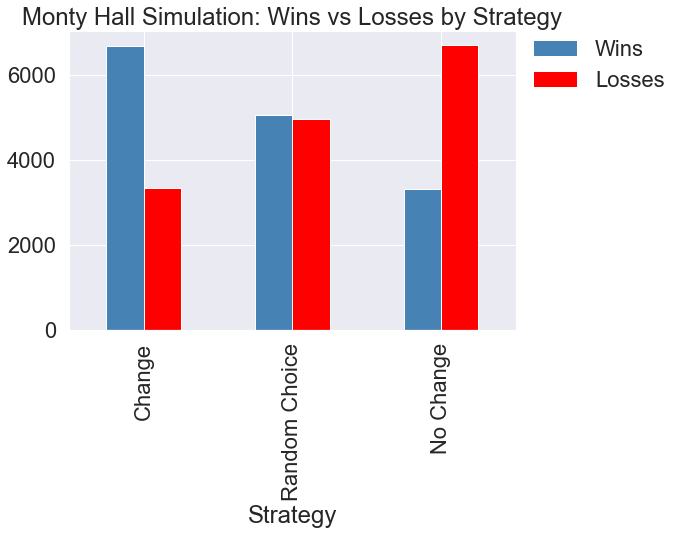

In [11]:
# Remove the Win Percentage column so that only wins and losses are shown then 
# plot the stacked bar chart to show the relative wins between the strategies.

wl_df = global_df.drop(columns=['Win Percentage'])

# Set seaborn style

plt.style.use('seaborn')

sns.set(style='whitegrid')
sns.set(font_scale=2)

wl_df.set_index('Strategy').plot(kind='bar', stacked=False, color=['steelblue', 'red'])
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.title('Monty Hall Simulation: Wins vs Losses by Strategy')



### Observations

As expected, the winning strategy is for the player to always change their Door choice to the Door that Monty does not open up.  This strategy gives the player a 2/3 chance of winning the car.  

When the player selects an initial door, the player has a 1/3 chance of selecting the Door with the car (at this point, without any further knowledge, the probability of the car being behind any Door is 1/3).  The probability is therefore 2/3 for the car being behind one of the other two doors.  

However, this is where the Bayesian Framework comes into play and our perspective of the probability changes as more information becomes available.  Monty has knowledge of which door the car is behind and will only open up a Door that doesn't have the car.  Therefore, as Monty will open up one of the other doors (from what the player originally selected) that is guaranteed to be a goat, the probability of selecting the car is therefore changed.  It is now the same as giving the player the choice at the outset to switch from their originally selected Door (1/3 probability) to the two other Doors the player didn't select (2/3 probability).

If the player kept their original choice, they remain at having a 1/3 probability of selecting the car.  If the player was given thousands of chances and they randomly changed or kept their original Door selection, they would have a probability better than keeping their original Door choice (1/3) but not as good as always changing (2/3).  In this simulation, the player won about 1/2 of the time.

### Conclusion

In the Monty Hall problem, the best choice a player can make is to always change their original Door choice to the Door that Monty does not open up.  This gives the player the best probability (2/3) of winning the car.